# Anisotropy in 2D  

This tutorial illustrates how fiber rotation influences wave propagation speed in different directions.  

## Overview  

- **Tissue:** 2D grid of size `400 × 400`  
- **Models:**  
  - Aliev–Panfilov  
  - TP06  
- **Stimulation:** Apply `u = 1.0` at the center of the tissue  
- **Plots:**  
  - Activation wave  
  - Major and minor axes of the ellipse fitted to the activation wave  
  - Orientation angle of the ellipse  
  - Maximum and minimum values of `u`

## Reference

For numeric schemes refer to:
"Bram van Es, Barry Koren, Hugo J. de Blank,
Finite-difference schemes for anisotropic diffusion,
Journal of Computational Physics,
Volume 272,
2014,
Pages 526-549,
ISSN 0021-9991,
https://doi.org/10.1016/j.jcp.2014.04.046."

### Isotropic Conduction  

By default, if no fiber orientation is provided, isotropic conduction is assumed.  

In this example, we used:  
- Conductivity = `1.0`  
- Conductivity = `0.5` for half of the tissue  
- Conductivity = `0.5`  

Running AlievPanfilov2D: 100%|█████████▉| 2499/2500 [00:03<00:00, 800.60it/s]


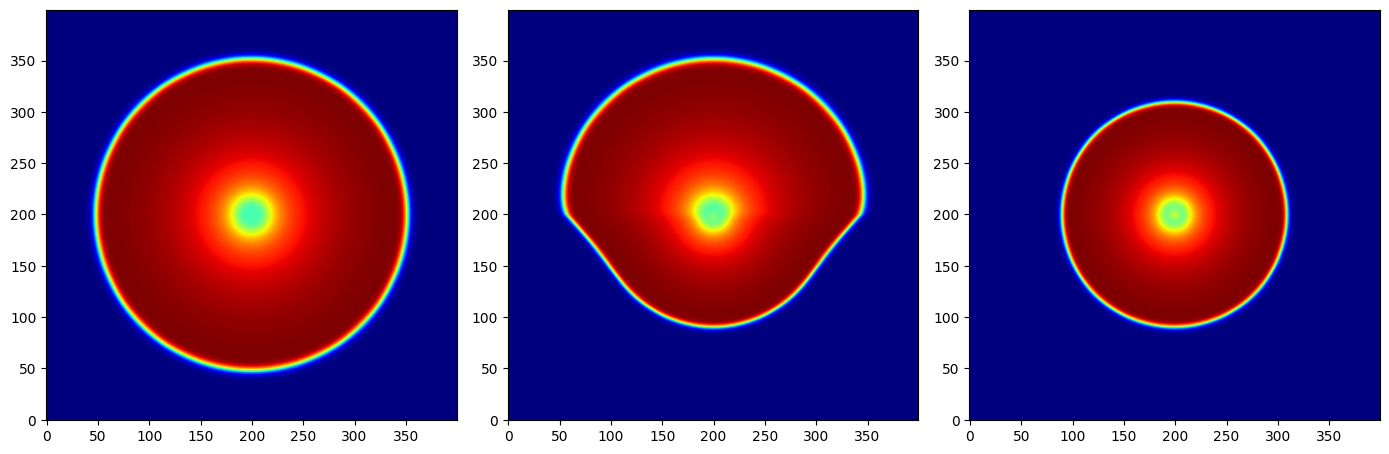

In [1]:

import matplotlib.pyplot as plt
import numpy as np
import skimage as ski
import pandas as pd

import finitewave as fw


# number of nodes on the side
n = 400

images = []
for c, n_max in zip([1, 0.5, 0.5], [-1, n//2, -1]):
    tissue = fw.CardiacTissue2D([n, n])
    tissue.conductivity = np.ones((n, n))
    tissue.conductivity[:n_max, :] = c

    # set up stimulation parameters:
    stim_sequence = fw.StimSequence()
    stim_sequence.add_stim(fw.StimVoltageCoord2D(0, 1, n//2 - 5, n//2 + 5,
                                                 n//2 - 5, n//2 + 5))
    
    # create model object and set up parameters
    model = fw.AlievPanfilov2D()
    model.dt = 0.01
    model.dr = 0.25
    model.t_max = 25
    model.cardiac_tissue = tissue
    model.stim_sequence = stim_sequence

    model.run()
    
    images.append(model.u.copy())


fig, axs = plt.subplots(ncols=len(images), figsize=(14, 7))

for i in range(len(images)):
    axs[i].imshow(images[i], origin='lower', cmap='jet')

plt.tight_layout()

### Anisotropic Conduction  

If fibers (a matrix of normalized vectors) are provided, the model will use  
`AsymmetricStencil`.  

This section demonstrates how the wave propagates for different fiber angles:  
- Conduction velocity (CV) along and across the fibers is calculated based on  
  the semi-major and semi-minor axes of the ellipses.  


[[15.4         0.        ]
 [ 0.          1.71111111]]
0 1 -1
0 1 1
1 0 -1
1 0 1
[1. 1. 1. ... 1. 1. 1.]


Running Courtemanche on [256, 256] Grid: 100%|██████████| 15000/15000 [00:53<00:00, 281.08it/s]


[[14.48301832  3.42222222]
 [ 3.42222222  2.62809279]]
0 1 -1
0 1 1
1 0 -1
1 0 1
[1. 1. 1. ... 1. 1. 1.]


Running Courtemanche on [256, 256] Grid: 100%|██████████| 15000/15000 [00:53<00:00, 281.32it/s]


[[11.97777778  5.92746276]
 [ 5.92746276  5.13333333]]
0 1 -1
0 1 1
1 0 -1
1 0 1
[1. 1. 1. ... 1. 1. 1.]


Running Courtemanche on [256, 256] Grid: 100%|██████████| 15000/15000 [00:53<00:00, 279.56it/s]


[[8.55555556 6.84444444]
 [6.84444444 8.55555556]]
0 1 -1
0 1 1
1 0 -1
1 0 1
[1. 1. 1. ... 1. 1. 1.]


Running Courtemanche on [256, 256] Grid: 100%|██████████| 15000/15000 [00:53<00:00, 282.21it/s]


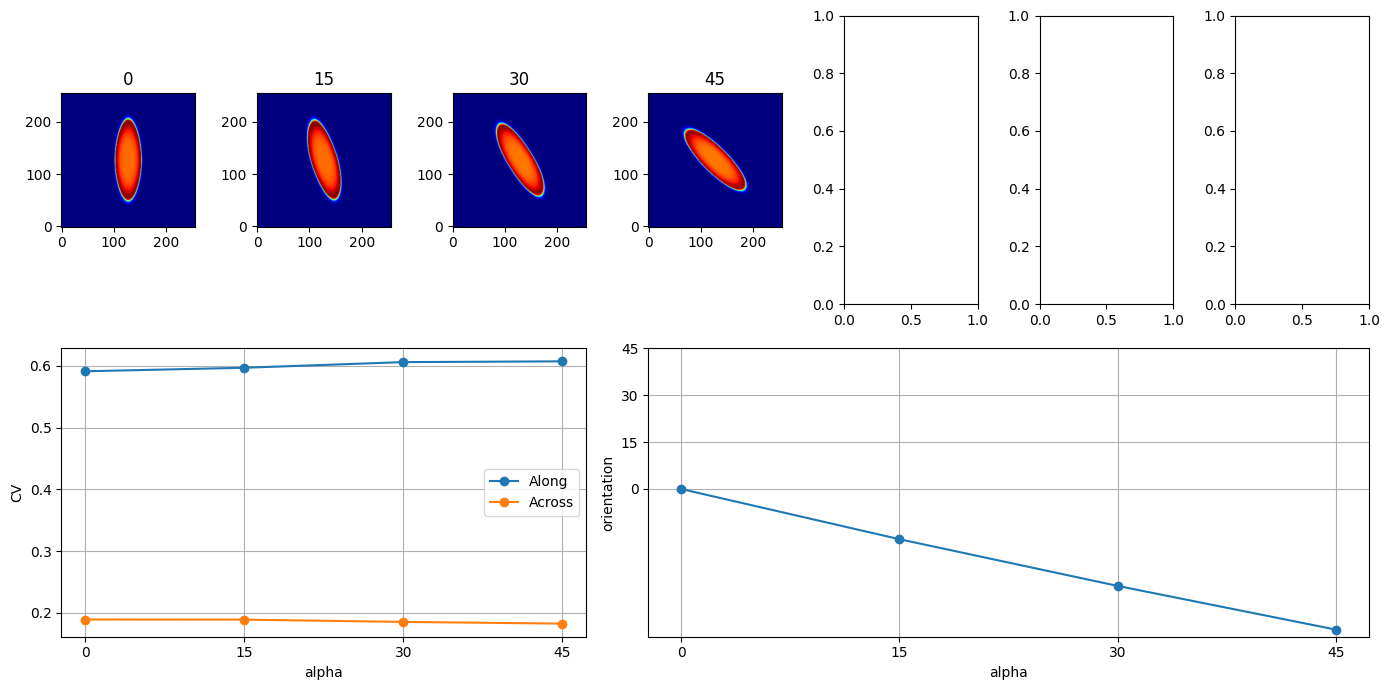

In [2]:

import matplotlib.pyplot as plt
import numpy as np
import skimage as ski
import pandas as pd

import finitewave as fw


# number of nodes on the side
n = 256

alphas = np.radians(np.arange(0, 91, 15))[:4]
out = []
images = []
for alpha in alphas:
    tissue = fw.CardiacTissueGrid([n, n])
    # tissue.mesh += (np.random.random(tissue.mesh.shape) < 0.1)
    # add fibers orientation vectors
    tissue.fibers = np.zeros([n, n, 2])
    tissue.fibers[:, :, 0] = np.cos(alpha)
    tissue.fibers[:, :, 1] = np.sin(alpha)

    diffusion_model = fw.GridAssembler()
    diffusion_model.stencil = fw.SymmetricStencil()

    # set up stimulation parameters:
    stim_sequence = fw.StimSequence()
    stim_sequence.add_stim(fw.StimVoltageCoord(time=0, volt_value=1,
                                            x_min=n//2 - 3, x_max=n//2 + 3,
                                            y_min=n//2 - 3, y_max=n//2 + 3))

    simulation = fw.CardiacSimulation()
    simulation.dt = 0.001
    simulation.dr = 0.1
    simulation.t_max = 15
    # add the tissue and the stim parameters to the model object:
    simulation.cardiac_tissue = tissue
    simulation.cardiac_model = fw.Courtemanche()
    simulation.cardiac_model.step = 2
    simulation.stim_sequence = stim_sequence
    simulation.diffusion_model = diffusion_model

    # run the model:
    simulation.run()

    u = simulation.cardiac_model.u.copy()
    
    # calculate properties of the wave
    labeled = (u > 0.1).astype(int)
    props = ski.measure.regionprops_table(labeled, properties=(
        'orientation', 'major_axis_length', 'minor_axis_length'))
    props['orientation'] = np.degrees(props['orientation'])
    props['axis_ratio'] = props['major_axis_length'] / props['minor_axis_length']
    props['alpha'] = np.degrees(alpha)
    props['density_calc'] = (np.sum(tissue.mesh[-1:1, -1:1] == 2) 
                                / ((n - 2) * (n - 2)))
    images.append(u)

    out.append(pd.DataFrame(props))

out = pd.concat(out)


cv_along = out['major_axis_length'] / 2 * simulation.dr / simulation.t_max
cv_across = out['minor_axis_length'] / 2 * simulation.dr / simulation.t_max

fig, axs = plt.subplot_mosaic([[f'{i}' for i in range(7)],
                               ['axis_ratio'] * 3 + ['orientation']*4],
                               figsize=(14, 7))

for i in range(len(alphas)):
    ax = axs[f'{i}']
    ax.imshow(images[i], cmap='jet', origin='lower')
    ax.set_title(f'{np.degrees(alphas[i]):.0f}')

ax = axs['axis_ratio']
ax.plot(out['alpha'], cv_along, 'o-', label='Along')
ax.plot(out['alpha'], cv_across, 'o-', label='Across')
ax.set_xlabel('alpha')
ax.set_ylabel('CV')
ax.set_xticks(np.degrees(alphas))
ax.grid(True)
ax.legend()

ax = axs['orientation']
ax.plot(out['alpha'], out['orientation'], 'o-')
ax.set_xlabel('alpha')
ax.set_ylabel('orientation')
ax.set_xticks(np.degrees(alphas))
ax.set_yticks(np.degrees(alphas))
ax.grid(True)

plt.tight_layout()
plt.show()

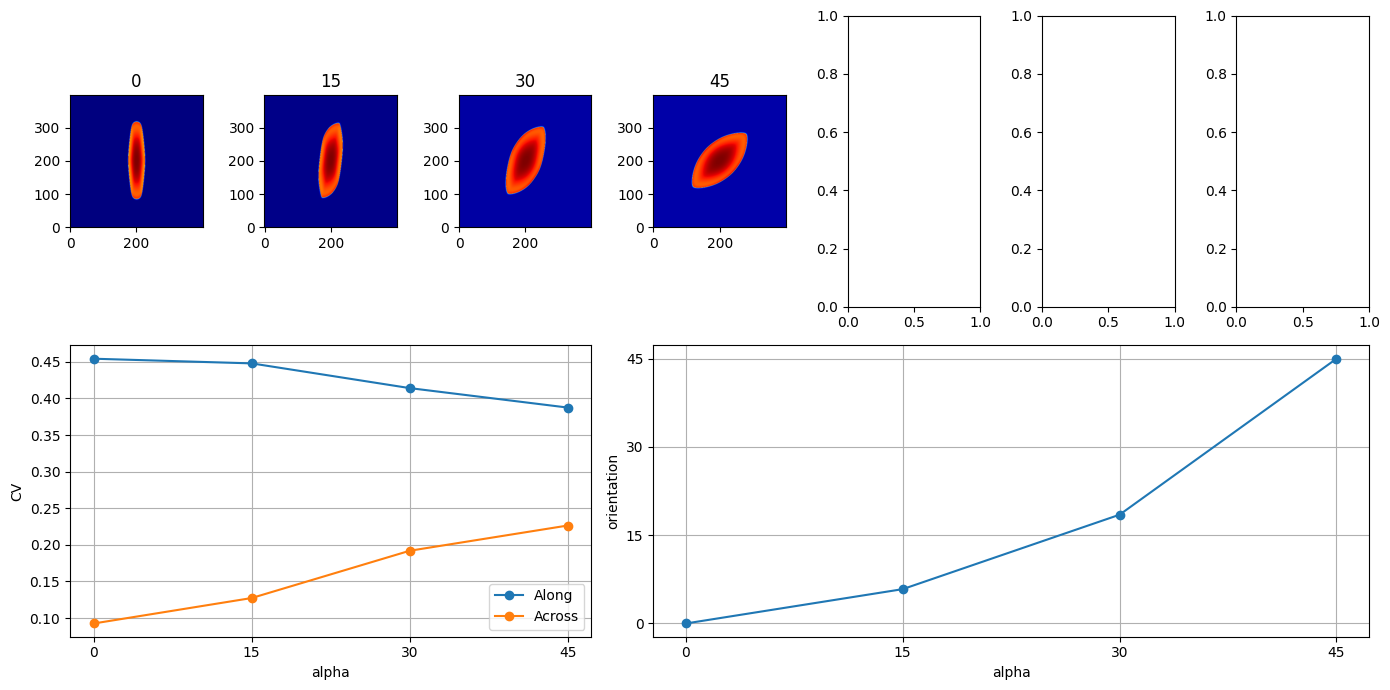

In [4]:
cv_along = out['major_axis_length'] / 2 * simulation.dr / simulation.t_max
cv_across = out['minor_axis_length'] / 2 * simulation.dr / simulation.t_max

fig, axs = plt.subplot_mosaic([[f'{i}' for i in range(7)],
                               ['axis_ratio'] * 3 + ['orientation']*4],
                               figsize=(14, 7))

for i in range(len(alphas)):
    ax = axs[f'{i}']
    ax.imshow(images[i], cmap='jet', origin='lower')
    ax.set_title(f'{np.degrees(alphas[i]):.0f}')

ax = axs['axis_ratio']
ax.plot(out['alpha'], cv_along, 'o-', label='Along')
ax.plot(out['alpha'], cv_across, 'o-', label='Across')
ax.set_xlabel('alpha')
ax.set_ylabel('CV')
ax.set_xticks(np.degrees(alphas))
ax.grid(True)
ax.legend()

ax = axs['orientation']
ax.plot(out['alpha'], out['orientation'], 'o-')
ax.set_xlabel('alpha')
ax.set_ylabel('orientation')
ax.set_xticks(np.degrees(alphas))
ax.set_yticks(np.degrees(alphas))
ax.grid(True)

plt.tight_layout()
plt.show()

As an alternative, `SymmetricStencil` can be used.  
This approach provides a better CV ratio.  

⚠️ Note: This method is unstable when used with fibrosis.  


Running AlievPanfilov2D: 100%|█████████▉| 2499/2500 [00:02<00:00, 914.46it/s]


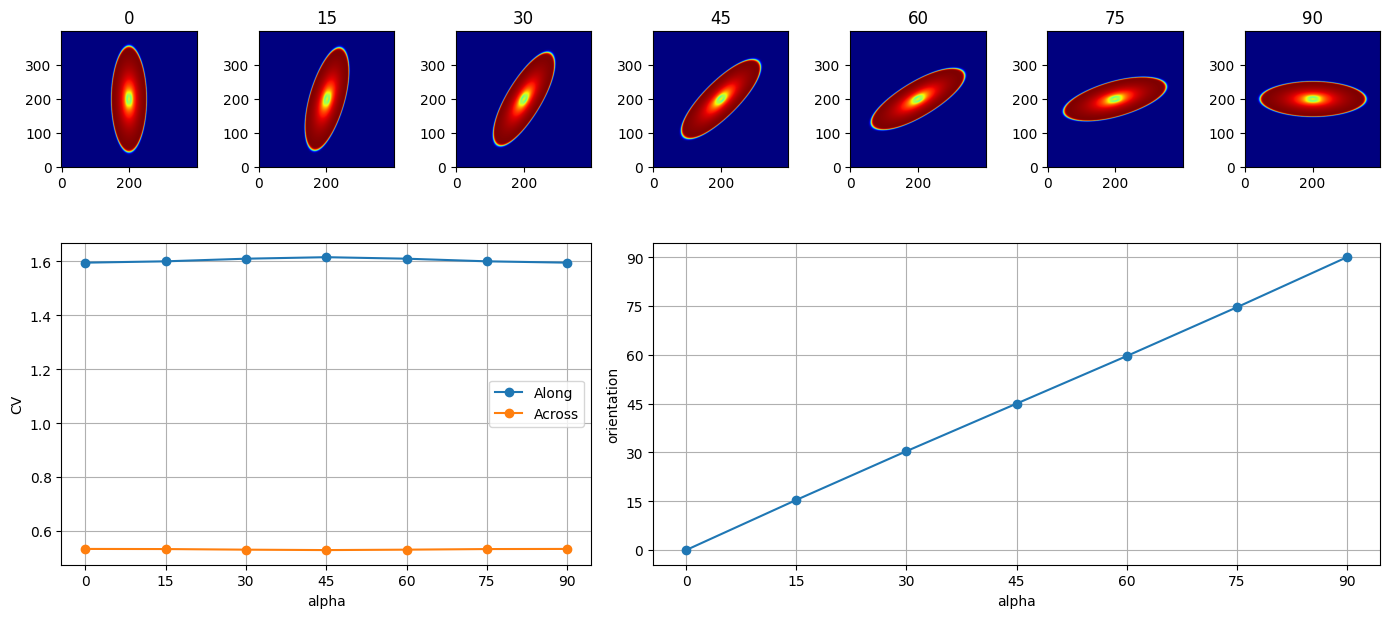

In [4]:

import matplotlib.pyplot as plt
import numpy as np
import skimage as ski
import pandas as pd

import finitewave as fw


# number of nodes on the side
n = 400

alphas = np.radians(np.arange(0, 91, 15))
out = []
images = []
for alpha in alphas:
    tissue = fw.CardiacTissue2D([n, n])
    # add fibers orientation vectors
    tissue.fibers = np.zeros([n, n, 2])
    tissue.fibers[..., 0] = np.cos(alpha)
    tissue.fibers[..., 1] = np.sin(alpha)

    # set up stimulation parameters:
    stim_sequence = fw.StimSequence()
    stim_sequence.add_stim(fw.StimVoltageCoord2D(0, 1, n//2 - 5, n//2 + 5,
                                                 n//2 - 5, n//2 + 5))
    
    # create model object and set up parameters
    model = fw.AlievPanfilov2D()
    model.dt = 0.01
    model.dr = 0.25
    model.t_max = 25
    model.stencil = fw.SymmetricStencil2D()
    model.cardiac_tissue = tissue
    model.stim_sequence = stim_sequence

    model.run()
    
    # calculate properties of the wave
    labeled = (model.u > 0.1).astype(int)
    props = ski.measure.regionprops_table(labeled, properties=(
        'orientation', 'major_axis_length', 'minor_axis_length'))
    props['orientation'] = np.degrees(props['orientation'])
    props['axis_ratio'] = props['major_axis_length'] / props['minor_axis_length']
    props['alpha'] = np.degrees(alpha)
    props['density_calc'] = (np.sum(tissue.mesh[-1:1, -1:1] == 2) 
                                / ((n - 2) * (n - 2)))
    images.append(model.u.copy())

    out.append(pd.DataFrame(props))

out = pd.concat(out)


cv_along = out['major_axis_length'] / 2 * model.dr / model.t_max
cv_across = out['minor_axis_length'] / 2 * model.dr / model.t_max

fig, axs = plt.subplot_mosaic([[f'{i}' for i in range(7)],
                               ['axis_ratio'] * 3 + ['orientation']*4],
                               figsize=(14, 7))

for i in range(len(alphas)):
    ax = axs[f'{i}']
    ax.imshow(images[i], cmap='jet', origin='lower')
    ax.set_title(f'{np.degrees(alphas[i]):.0f}')

ax = axs['axis_ratio']
ax.plot(out['alpha'], cv_along, 'o-', label='Along')
ax.plot(out['alpha'], cv_across, 'o-', label='Across')
ax.set_xlabel('alpha')
ax.set_ylabel('CV')
ax.set_xticks(np.degrees(alphas))
ax.grid(True)
ax.legend()

ax = axs['orientation']
ax.plot(out['alpha'], out['orientation'], 'o-')
ax.set_xlabel('alpha')
ax.set_ylabel('orientation')
ax.set_xticks(np.degrees(alphas))
ax.set_yticks(np.degrees(alphas))
ax.grid(True)

plt.tight_layout()
plt.show()

## Effect of Fibrosis on Anisotropy

This section explores the impact of fibrosis on the anisotropy of wave propagation in cardiac tissue. By introducing fibrosis into the tissue model, we can observe changes in wave speed and directionality. The simulations are performed for different fiber orientations (alpha values), and the resulting wave properties, such as orientation, axis lengths, and axis ratios, are analyzed to understand the effects of fibrosis on anisotropy.

Running AlievPanfilov2D: 100%|█████████▉| 2999/3000 [00:00<00:00, 3633.27it/s]


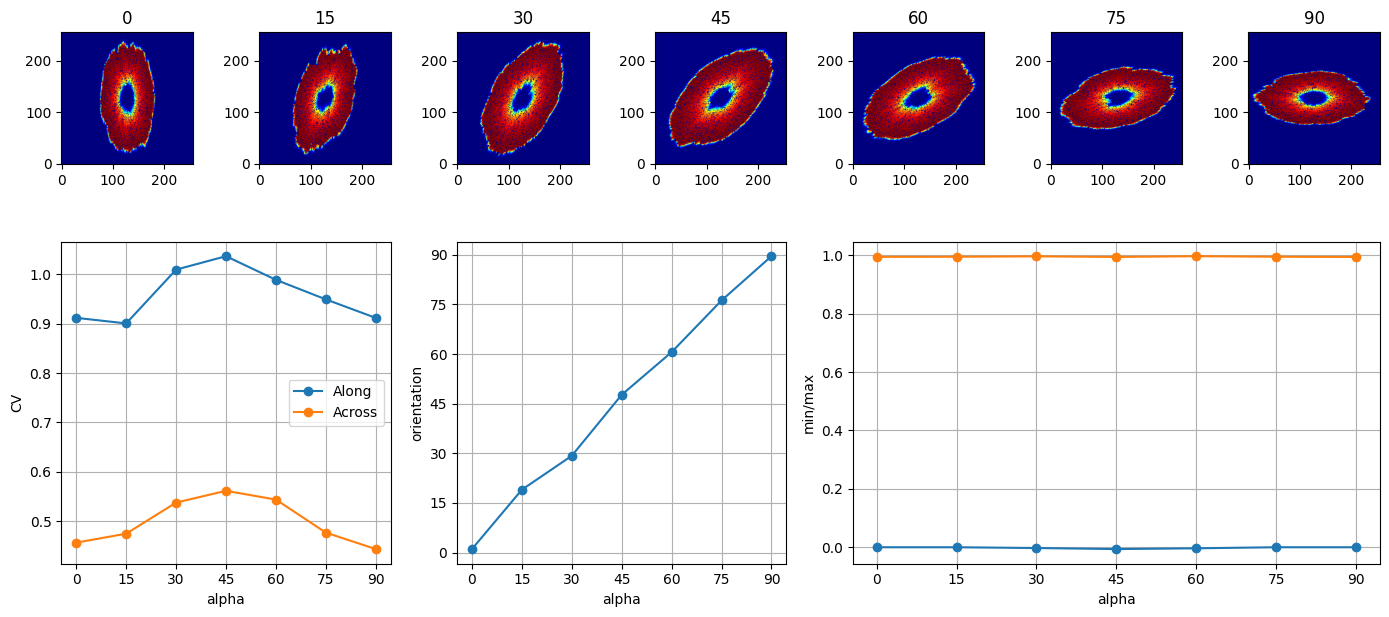

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import skimage as ski
import pandas as pd

import finitewave as fw

# number of nodes on the side
n = 256

alphas = np.radians(np.arange(0, 91, 15))
d = 0.2  # 20% of the tissue is fibrotic
out_fib = []
images_fib = []
for alpha in alphas:
    tissue = fw.CardiacTissue2D([n, n])
    tissue.add_pattern(fw.Diffuse2DPattern(d))
    # add fibers orientation vectors
    tissue.fibers = np.zeros([n, n, 2])
    tissue.fibers[..., 0] = np.cos(alpha)
    tissue.fibers[..., 1] = np.sin(alpha)

    # set up stimulation parameters:
    stim_sequence = fw.StimSequence()
    stim_sequence.add_stim(fw.StimVoltageCoord2D(0, 1, n//2 - 5, n//2 + 5,
                                                 n//2 - 5, n//2 + 5))
    
    # create model object:
    model = fw.AlievPanfilov2D()
    # set up numerical parameters:
    model.dt = 0.01
    model.dr = 0.25
    model.t_max = 30
    model.cardiac_tissue = tissue
    model.stim_sequence = stim_sequence

    model.run()

    labeled = (model.u > 0.5).astype(int)
    props = ski.measure.regionprops_table(
        labeled, properties=('orientation', 'major_axis_length',
                             'minor_axis_length'))
    props['orientation'] = np.degrees(props['orientation'])
    props['axis_ratio'] = props['major_axis_length'] / props['minor_axis_length']
    props['alpha'] = np.degrees(alpha)
    props['density_calc'] = (np.sum(tissue.mesh[-1:1, -1:1] == 2) 
                                / ((n - 2) * (n - 2)))
    images_fib.append(model.u.copy())

    out_fib.append(pd.DataFrame(props))

out_fib = pd.concat(out_fib)


cv_along = out_fib['major_axis_length'] / 2 * model.dr / model.t_max
cv_across = out_fib['minor_axis_length'] / 2 * model.dr / model.t_max

fig, axs = plt.subplot_mosaic([[f'{i}' for i in range(7)],
                               ['axis_ratio'] * 2 + ['orientation']*2 +
                               ['min_max'] * 3],
                               figsize=(14, 7))

mins = []
maxs = []
for i in range(len(alphas)):
    ax = axs[f'{i}']
    ax.imshow(images_fib[i], cmap='jet', origin='lower')
    ax.set_title(f'{np.degrees(alphas[i]):.0f}')

    mins.append(images_fib[i].min())
    maxs.append(images_fib[i].max())
    

ax = axs['axis_ratio']
ax.plot(out_fib['alpha'], cv_along, 'o-', label='Along')
ax.plot(out_fib['alpha'], cv_across, 'o-', label='Across')
ax.set_xlabel('alpha')
ax.set_ylabel('CV')
ax.set_xticks(np.degrees(alphas))
ax.grid(True)
ax.legend()

out_fib.loc[out_fib['orientation'] < 0, 'orientation'] += 180

orientation = out_fib['orientation'].values
orientation[orientation > 90] = 180 - orientation[orientation > 90]

ax = axs['orientation']
ax.plot(out_fib['alpha'], orientation, 'o-')
ax.set_xlabel('alpha')
ax.set_ylabel('orientation')
ax.set_xticks(np.degrees(alphas))
ax.set_yticks(np.degrees(alphas))
ax.grid(True)

ax = axs['min_max']
ax.plot(np.degrees(alphas), mins, 'o-', label='min')
ax.plot(np.degrees(alphas), maxs, 'o-', label='max')
ax.set_xlabel('alpha')
ax.set_ylabel('min/max')
ax.set_xticks(np.degrees(alphas))
ax.grid(True)

plt.tight_layout()
plt.show()

## Using TP06 Model

When using ionic model using smaller step (compared to the calculation without fibers) can be nessesary otherwise the calculation can be unstable.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import skimage as ski
import pandas as pd

import finitewave as fw

# number of nodes on the side
n = 256
# dt = 0.001
# dr = 0.1
# t_max = 20

alphas = np.radians(np.arange(0, 91, 15))
d = 0.2
out_lr_fib = []
images_lr_fib = []
for alpha in alphas:
    tissue = fw.CardiacTissueGrid([n, n])
    # tissue.mesh += (np.random.random(tissue.mesh.shape) < 0.1)
    # add fibers orientation vectors
    tissue.fibers = np.zeros([n, n, 2])
    tissue.fibers[:, :, 0] = np.cos(alpha)
    tissue.fibers[:, :, 1] = np.sin(alpha)

    diffusion_model = fw.GridAssembler()
    diffusion_model.stencil = fw.AsymmetricStencil()

    # set up stimulation parameters:
    stim_sequence = fw.StimSequence()
    stim_sequence.add_stim(fw.StimVoltageCoord(time=0, volt_value=1,
                                            x_min=n//2 - 3, x_max=n//2 + 3,
                                            y_min=n//2 - 3, y_max=n//2 + 3))

    simulation = fw.CardiacSimulation()
    simulation.dt = 0.01
    simulation.dr = 0.25
    simulation.t_max = 50
    # add the tissue and the stim parameters to the model object:
    simulation.cardiac_tissue = tissue
    simulation.cardiac_model = fw.Courtemanche()
    simulation.stim_sequence = stim_sequence
    simulation.diffusion_model = diffusion_model

    # run the model:
    simulation.run()


    labeled = (model.u > 0.).astype(int)
    props = ski.measure.regionprops_table(
        labeled, properties=('orientation', 'major_axis_length',
                             'minor_axis_length'))
    props['orientation'] = np.degrees(props['orientation'])
    props['axis_ratio'] = props['major_axis_length'] / props['minor_axis_length']
    props['alpha'] = np.degrees(alpha)
    props['density_calc'] = (np.sum(tissue.mesh[-1:1, -1:1] == 2) 
                                / ((n - 2) * (n - 2)))
    images_lr_fib.append(model.u.copy())

    out_lr_fib.append(pd.DataFrame(props))

out_lr_fib = pd.concat(out_lr_fib)

Running TP062D: 100%|█████████▉| 19999/20000 [01:22<00:00, 243.64it/s]


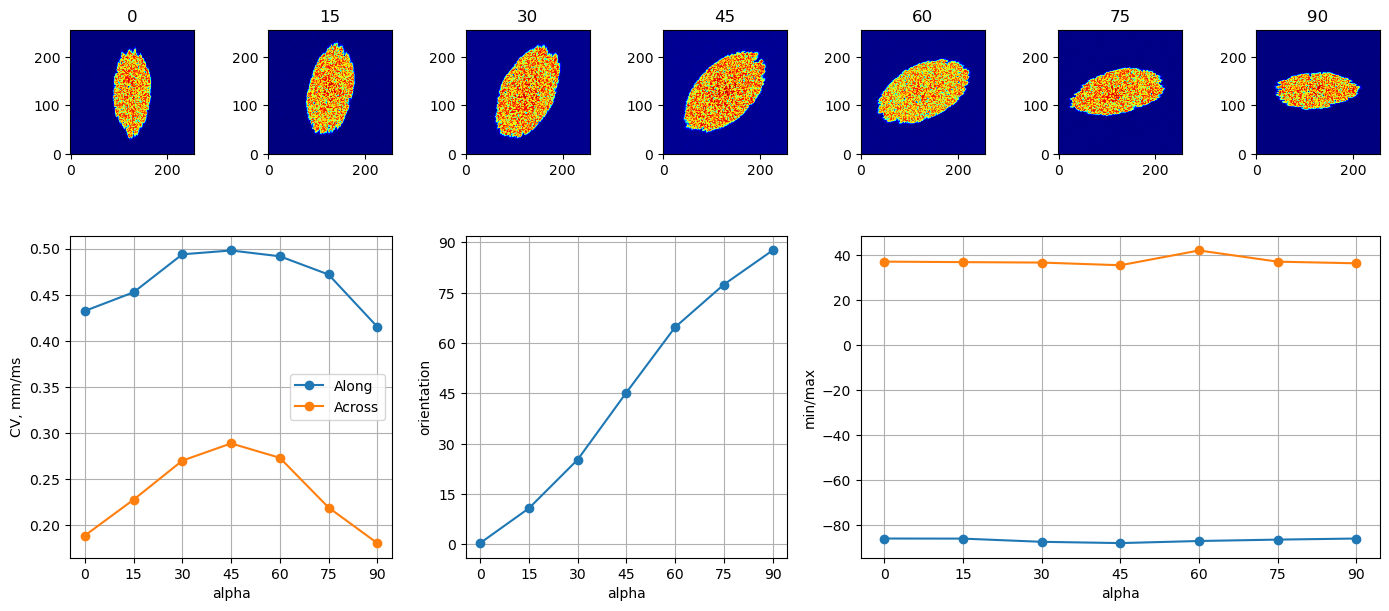

In [6]:
cv_along = out_lr_fib['major_axis_length'] / 2 * model.dr / model.t_max
cv_across = out_lr_fib['minor_axis_length'] / 2 * model.dr / model.t_max

fig, axs = plt.subplot_mosaic([[f'{i}' for i in range(7)],
                               ['axis_ratio'] * 2 + ['orientation']*2 +
                               ['min_max'] * 3],
                               figsize=(14, 7))

mins = []
maxs = []
for i in range(len(alphas)):
    ax = axs[f'{i}']
    ax.imshow(images_lr_fib[i], cmap='jet', origin='lower')
    ax.set_title(f'{np.degrees(alphas[i]):.0f}')

    mins.append(images_lr_fib[i].min())
    maxs.append(images_lr_fib[i].max())
    

ax = axs['axis_ratio']
ax.plot(out_lr_fib['alpha'], cv_along, 'o-', label='Along')
ax.plot(out_lr_fib['alpha'], cv_across, 'o-', label='Across')
ax.set_xlabel('alpha')
ax.set_ylabel('CV, mm/ms')
ax.set_xticks(np.degrees(alphas))
ax.grid(True)
ax.legend()

out_lr_fib.loc[out_lr_fib['orientation'] < 0, 'orientation'] += 180

orientation = out_lr_fib['orientation'].values
orientation[orientation > 90] = 180 - orientation[orientation > 90]

ax = axs['orientation']
ax.plot(out_lr_fib['alpha'], orientation, 'o-')
ax.set_xlabel('alpha')
ax.set_ylabel('orientation')
ax.set_xticks(np.degrees(alphas))
ax.set_yticks(np.degrees(alphas))
ax.grid(True)

ax = axs['min_max']
ax.plot(np.degrees(alphas), mins, 'o-', label='min')
ax.plot(np.degrees(alphas), maxs, 'o-', label='max')
ax.set_xlabel('alpha')
ax.set_ylabel('min/max')
ax.set_xticks(np.degrees(alphas))
ax.grid(True)

plt.tight_layout()
plt.show()